Isidora Popovic\
2024/3285\
Zadatak1 Taksi

Za potrebu izrade ovog zadatka odabrana su dva grada.\
Prvi je Beograd, gde je cena vožnje 105 dinara po započetom kilometru, a startna tarifa iznosi 320 dinara. Za noćnu vožnju cena po kilometru je 135 dinara.\
Drugi grad je Pariz, u kome važi tarifa od 8 evra (936 dinara) za 2,7 kilometara vožnje, posle čega je cena po kilometru 1,3 evra, tj. 150 dinara. Cena noćne vožnje je takođe 936 dinara, ali za 4,3 kilometra vožnje, dok je cena po kilometru 1,7 evra, tj. 200 dinara.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd 
import os 

In [2]:
def cenapokm(start, brojkm, cena1, cena2, tarifa):
    if tarifa==1:
        return start+cena1*brojkm
    elif tarifa==2:
        return start+cena2*brojkm
    else:    return 0

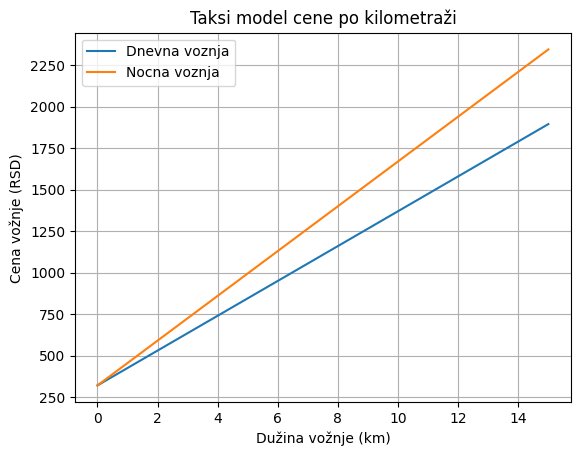

In [3]:
xval=np.linspace(0,15,100)  
voznja1=cenapokm(320,xval,105,135,1)
voznja2=cenapokm(320,xval,105,135,2)
plt.figure()
plt.plot(xval, voznja1)
plt.plot(xval, voznja2)
plt.legend(['Dnevna voznja', 'Nocna voznja'])
plt.xlabel("Dužina vožnje (km)")
plt.ylabel("Cena vožnje (RSD)")
plt.title("Taksi model cene po kilometraži")
plt.grid()

In [4]:
def fiksna_cena(start, brojkm, brojkmmaks1, brojkmmaks2, cena1, cena2, tarifa):
    brojkm = np.array(brojkm)  

    if tarifa == 1:  
        return np.where(brojkm <= brojkmmaks1,
                        start,
                        start + (brojkm - brojkmmaks1) * cena1)
    elif tarifa == 2:
        return np.where(brojkm <= brojkmmaks2,
                        start,
                        start + (brojkm - brojkmmaks2) * cena2)
    else:
        return np.zeros_like(brojkm)

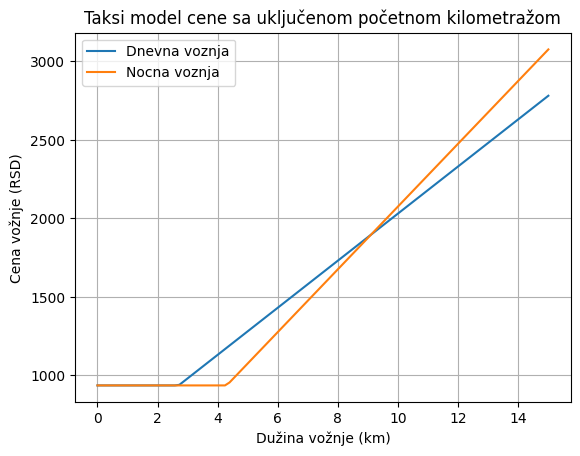

In [5]:
voznja3=fiksna_cena(936, xval, 2.7, 4.3,150,200,1)
voznja4=fiksna_cena(936, xval ,2.7, 4.3,150,200,2)
plt.figure()
plt.plot(xval, voznja3)
plt.plot(xval, voznja4)
plt.legend(['Dnevna voznja', 'Nocna voznja'])
plt.xlabel("Dužina vožnje (km)")
plt.title("Taksi model cene sa uključenom početnom kilometražom")
plt.ylabel("Cena vožnje (RSD)")
plt.grid()

Nacrtati grafike cene vožnje za oba grafika

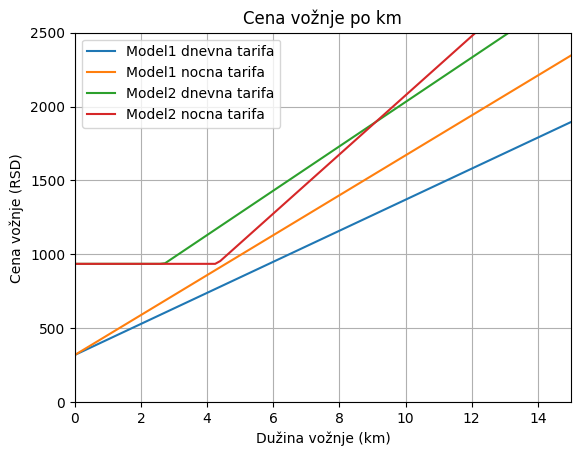

In [6]:
plt.figure()
plt.plot(xval, voznja1, label='Model1 dnevna tarifa')
plt.plot(xval, voznja2, label='Model1 nocna tarifa')
plt.plot(xval, voznja3, label='Model2 dnevna tarifa')
plt.plot(xval, voznja4, label='Model2 nocna tarifa')
plt.title('Cena vožnje po km')
plt.xlabel("Dužina vožnje (km)")
plt.ylabel("Cena vožnje (RSD)")
plt.xlim([0,15])
plt.ylim([0,2500])
plt.grid()
plt.legend(loc='best')


Uporediti ova dva modela — koji model je povoljniji za korisnika taksi usluge? Da li povoljnost modela cene zavisi od dužine vožnje, i ako da, na koji način

cena je vožnje jeftnija za model 2

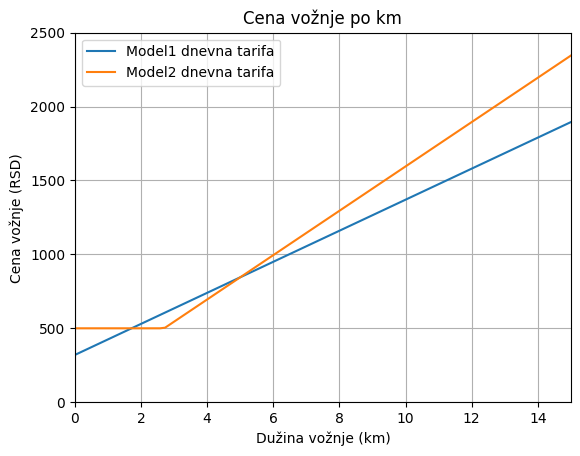

In [7]:
voznja5=fiksna_cena(500, xval, 2.7, 4.3,150,200,1)

plt.plot(xval, voznja1, label='Model1 dnevna tarifa')
plt.plot(xval, voznja5, label='Model2 dnevna tarifa')
plt.title('Cena vožnje po km')
plt.xlabel("Dužina vožnje (km)")
plt.ylabel("Cena vožnje (RSD)")
plt.xlim([0,15])
plt.ylim([0,2500])
plt.grid()
plt.legend(loc='best')

In [8]:
def preseci(x, y1, y2):
    razlika = y1 - y2
    tacke = []
    for i in range(len(x)-1):
        if razlika[i] == 0:  # tačno poklapanje
            tacke.append((x[i], y1[i]))
        elif razlika[i] * razlika[i+1] < 0:  # promena znaka -> seku se
            # linearna interpolacija između tačaka
            x_presek = (x[i] + x[i+1]) / 2
            y_presek = (y1[i] + y1[i+1]) / 2
            tacke.append((x_presek, y_presek))
    return tacke

In [9]:
preseci(xval, voznja1, voznja5)

[(1.7424242424242427, 502.9545454545455), (5.0, 845.0)]

Na koji način promena cene po kilometru u modelu 1 menja odnos ovog modela sa modelom 2, bez promene cena u modelu 2?\
Na koji način promena cene po kilometru u modelu 2 menja odnos ovog modela sa modelom 1, bez promene cena u modelu 1

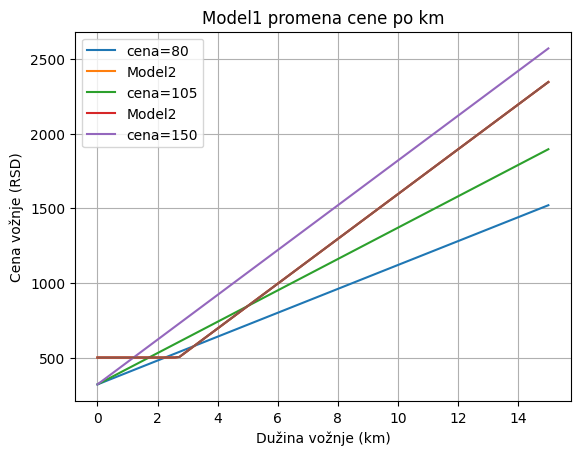

In [10]:
cena=[80,105,150]
for c in cena:
    voznja = cenapokm(320, xval, c, 135, 1)
    plt.plot(xval, voznja, label=f"cena={c}")
    plt.title('Model1 promena cene po km')
    plt.xlabel("Dužina vožnje (km)")
    plt.ylabel("Cena vožnje (RSD)")
    plt.grid()
    plt.legend(loc='best')
    plt.plot(xval, voznja5,label='Model2')

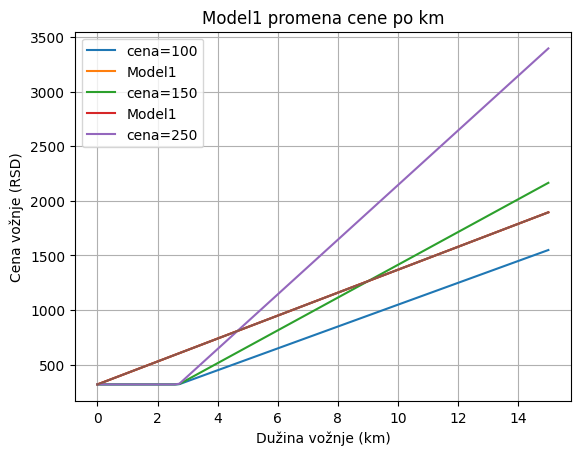

In [11]:
cena=[100,150,250]
for c in cena:
    voznja = fiksna_cena(320, xval, 2.7, 4.3, c, 135, 1)
    plt.plot(xval, voznja, label=f"cena={c}")
    plt.title('Model1 promena cene po km')
    plt.xlabel("Dužina vožnje (km)")
    plt.ylabel("Cena vožnje (RSD)")
    plt.grid()
    plt.legend(loc='best')
    plt.plot(xval, voznja1, label='Model1')

Na ovom primeru vidimo da je model 2 jeftiniji za kraće razdaljine, iako cena po kilometru u modelu 2 raste. Sa porastom cene po kilometru, nagib krive se povećava

In [12]:
voznja = fiksna_cena(320, xval, 2.7, 4.3, 150, 135, 1)
print(preseci(xval, voznja1, voznja))
voznja = fiksna_cena(320, xval, 2.7, 4.3, 250, 135, 1)
print(preseci(xval, voznja1, voznja))

[(0.0, 320.0), (9.015151515151516, 1266.590909090909)]
[(0.0, 320.0), (4.621212121212121, 805.2272727272727)]


Litreuatura:\
https://www.taxi-calculator.com/taxi-rate
Yang, Hai, et al. "Nonlinear pricing of taxi services." Transportation Research Part A: Policy and Practice 44.5 (2010): 337-348.